In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"navadeepreddyduttala","key":"e510f19b448ca6f5610e5b4199f6e400"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d xiaopengzhang12/lung-cancer-mri-images

Dataset URL: https://www.kaggle.com/datasets/xiaopengzhang12/lung-cancer-mri-images
License(s): unknown
 96% 501M/522M [00:07<00:00, 81.3MB/s]
100% 522M/522M [00:10<00:00, 52.7MB/s]


In [ ]:
!unzip lung-cancer-mri-images.zip

Archive:  lung-cancer-mri-images.zip
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (10).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (100).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1000).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1001).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1002).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1003).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1004).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1005).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1006).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1007).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1008).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1009).png  
  inflating: lung_cancer_MRI_data

In [ ]:
import zipfile

with zipfile.ZipFile("lung-cancer-mri-images.zip", 'r') as zip_ref:
    zip_ref.extractall("lung_dataset")

In [ ]:
import os
os.listdir("lung_dataset")

['lung_cancer_MRI_dataset']

In [ ]:
import shutil
import random
import os

source_base_path = "lung_dataset/lung_cancer_MRI_dataset" # This is where 'train' and 'validate' reside
train_dest_dir = "lung_data/train"
val_dest_dir = "lung_data/val"

# Ensure the top-level destination directories exist
# First, remove existing lung_data directory to ensure a clean slate
if os.path.exists("lung_data"):
    shutil.rmtree("lung_data")
os.makedirs(train_dest_dir, exist_ok=True)
os.makedirs(val_dest_dir, exist_ok=True)

# Collect all image paths and their corresponding class labels
all_images = []
class_labels = set()

# Iterate through original 'train' and 'validate' directories
for split_folder in os.listdir(source_base_path): # e.g., 'train', 'validate'
    split_folder_path = os.path.join(source_base_path, split_folder)
    if os.path.isdir(split_folder_path):
        # Iterate through class subdirectories (e.g., 'cancer', 'normal')
        for class_name in os.listdir(split_folder_path):
            class_path = os.path.join(split_folder_path, class_name)
            if os.path.isdir(class_path):
                class_labels.add(class_name) # Keep track of all unique class names
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')): # Filter for image files
                        image_path = os.path.join(class_path, img_name)
                        all_images.append({'path': image_path, 'class': class_name})

# Now, create destination class directories
for class_name in class_labels:
    os.makedirs(os.path.join(train_dest_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dest_dir, class_name), exist_ok=True)

# Separate images by class for a stratified split
images_by_class = {label: [] for label in class_labels}
for img_info in all_images:
    images_by_class[img_info['class']].append(img_info['path'])

train_set = []
val_set = []

# Perform stratified split for each class
for class_name, paths in images_by_class.items():
    random.shuffle(paths)
    split_idx = int(0.8 * len(paths))
    train_set.extend([(p, class_name) for p in paths[:split_idx]])
    val_set.extend([(p, class_name) for p in paths[split_idx:]])

# Copy files to the new train and validation directories
for img_path, class_name in train_set:
    dest_path = os.path.join(train_dest_dir, class_name, os.path.basename(img_path))
    shutil.copy(img_path, dest_path)

for img_path, class_name in val_set:
    dest_path = os.path.join(val_dest_dir, class_name, os.path.basename(img_path))
    shutil.copy(img_path, dest_path)

In [ ]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder("lung_data/train", transform=transform)
val_dataset = datasets.ImageFolder("lung_data/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['cancer', 'no_cancer']


In [ ]:
model = models.densenet121(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 181MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)   # 2 classes

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    # Calculate average training loss for the epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation phase ---
    model.eval()
    running_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    # Calculate average validation loss for the epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch [1/10], Train Loss: 0.3508, Val Loss: 0.3634
Epoch [2/10], Train Loss: 0.3375, Val Loss: 0.4063
Epoch [3/10], Train Loss: 0.3197, Val Loss: 0.3820
Epoch [4/10], Train Loss: 0.3245, Val Loss: 0.3929
Epoch [5/10], Train Loss: 0.3561, Val Loss: 0.5941
Epoch [6/10], Train Loss: 0.3601, Val Loss: 0.3820
Epoch [7/10], Train Loss: 0.3154, Val Loss: 0.3816
Epoch [8/10], Train Loss: 0.2976, Val Loss: 0.8305
Epoch [9/10], Train Loss: 0.3098, Val Loss: 0.3624
Epoch [10/10], Train Loss: 0.3404, Val Loss: 0.3747


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 64.64088397790056


In [ ]:
torch.save(model.state_dict(), "densenet121_lung_model.pth")

In [ ]:
from google.colab import files
files.download("densenet121_lung_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

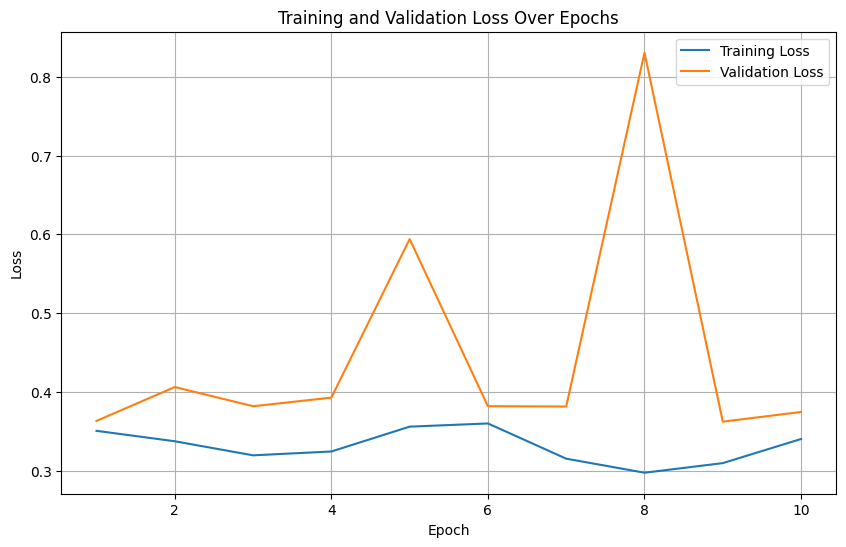

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[247 115]
 [  0 362]]


In [ ]:
class_names = train_dataset.classes
print(classification_report(all_labels, all_preds,
                            target_names=class_names))

              precision    recall  f1-score   support

      cancer       1.00      0.68      0.81       362
   no_cancer       0.76      1.00      0.86       362

    accuracy                           0.84       724
   macro avg       0.88      0.84      0.84       724
weighted avg       0.88      0.84      0.84       724



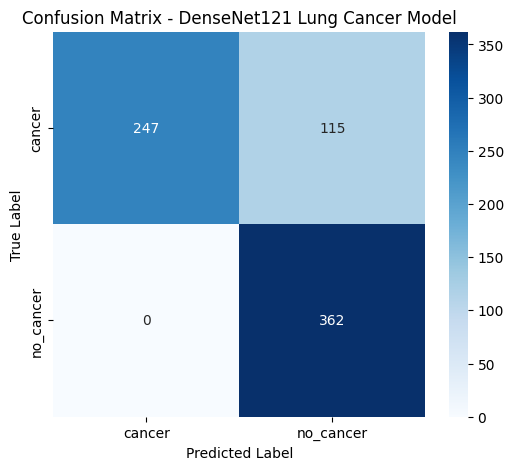

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121 Lung Cancer Model")
plt.show()